# TZ Fornacis synthetic spectra

Generate synthetic spectra for the TZ Fornacis binary system: a G-type giant primary and an F-type subgiant secondary. The spectra are simulated with an `astro_emulators_toolkit` pretrained intensity emulator over one orbital period and saved to a pickle file for downstream analysis.

This notebook is the interactive counterpart of `tz_fornacis_spectra.py`, updated for the current SPICE API (`spice.spectrum.aemu_spectrum_emulator`).

In [ ]:
import jax
jax.config.update("jax_enable_x64", True)

In [ ]:
import matplotlib
%matplotlib inline

In [ ]:
from spice.models.binary import Binary, add_orbit, evaluate_orbit_at_times
from spice.models.mesh_model import IcosphereModel
from spice.models.mesh_view import get_mesh_view
from spice.models.orbit_utils import eclipse_timestamps_kepler
from spice.spectrum import simulate_observed_flux
from spice.spectrum.aemu_spectrum_emulator import IntensityPretrainedAemuSpectrumEmulator
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import jax.numpy as jnp
import pickle
import os
from tqdm import tqdm

## Parameters

These were command-line options in the script. Edit them here instead.

In [ ]:
num_times = 150          # Number of time points to sample
num_wavelengths = 40000  # Number of wavelength points
output_dir = 'data'      # Directory to save output files

## Load the pretrained intensity emulator

In [ ]:
em = IntensityPretrainedAemuSpectrumEmulator('RozanskiT/TPayne-spice-harps')

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

E0514 19:28:57.123114  241666 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0514 19:28:57.123317  241667 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0514 19:28:57.123449  241668 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## Build the stellar models

Primary: G-type giant. Secondary: F-type subgiant. `override_log_g=False` keeps the literature surface gravities rather than recomputing log g from the mesh geometry.

In [ ]:
body1 = IcosphereModel.construct(
    500, 8.28, 2.057,
    em.to_parameters(dict(teff=4930, logg=2.91)),
    em.stellar_parameter_names,
    override_log_g=False,
)

/scratch/y89/mj8805/miniforge/envs/astro/lib/python3.11/site-packages/spice/spectrum/aemu_spectrum_emulator.py:57: UserWarning: Possible exceeding parameter bonds - extrapolating.
  warnings.warn("Possible exceeding parameter bonds - extrapolating.")


[spice] IcosphereModel constructed in 3.5 s


In [ ]:
body2 = IcosphereModel.construct(
    500, 3.94, 1.958,
    em.to_parameters(dict(teff=6650, logg=3.35)),
    em.stellar_parameter_names,
    override_log_g=False,
)

[spice] IcosphereModel constructed in 0.0 s


## Set up the binary system with orbital parameters

In [ ]:
binary = Binary.from_bodies(body1, body2)
binary = add_orbit(binary, (75.6*u.d).to(u.year).value, 0., 0., jnp.deg2rad(85.68), jnp.deg2rad(65.99), jnp.deg2rad(269.), 0., 0., 0., 15)

## Compute eclipse times

Use `eclipse_timestamps_kepler` to predict the first/last contact times of the primary and secondary eclipses from the same Keplerian elements passed to `add_orbit`. The line-of-sight convention `[0, 0, -1]` matches the rest of the SPICE pipeline (and `check_phoebe_eclipses.py`).

In [ ]:
period_yr = (75.6 * u.d).to(u.year).value
yr_to_day = (1 * u.year).to(u.day).value

(_, t1_p, _, _, t4_p,
 _, t1_s, _, _, t4_s) = eclipse_timestamps_kepler(
    2.057, 1.958,
    period_yr, 0., 0.,
    jnp.deg2rad(85.68),
    jnp.deg2rad(65.99),
    jnp.deg2rad(269.),
    8.28, 3.94,
    pad=1.1,
    los_vector=jnp.array([0., 0., -1.]),
)

primary_eclipse_window_yr = (float(t1_p), float(t4_p))
secondary_eclipse_window_yr = (float(t1_s), float(t4_s))

print(f"Primary eclipse window   [days]: {t1_p * yr_to_day:.3f} -> {t4_p * yr_to_day:.3f}")
print(f"Secondary eclipse window [days]: {t1_s * yr_to_day:.3f} -> {t4_s * yr_to_day:.3f}")

## Sample time points across the orbital period

In [9]:
times = jnp.linspace(0., (75.6*u.d).to(u.year).value, num_times).reshape((10, num_times//10))

## Evaluate orbital positions at each time point

In [10]:
result = [evaluate_orbit_at_times(binary, t) for t in tqdm(times)]
times = times.flatten()

pb1, pb2 = [], []
for r in result:
    pb1.extend(r[0])
    pb2.extend(r[1])

[spice] Binary orbit evaluated in 19.1 s                                                                                                                    
[spice] Binary orbit evaluated in 0.4 s                                                                                                                     
[spice] Binary orbit evaluated in 0.4 s                                                                                                                     
[spice] Binary orbit evaluated in 0.4 s                                                                                                                     
[spice] Binary orbit evaluated in 0.3 s                                                                                                                     
[spice] Binary orbit evaluated in 0.3 s                                                                                                                     
[spice] Binary orbit evaluated in 0.4 s                   

## Wavelength grid

In [11]:
vws = jnp.linspace(3000, 10000, num_wavelengths)

## Simulate spectra for the primary star

In [12]:
spectra_body1 = [simulate_observed_flux(em.intensity, _pb, jnp.log10(vws)) for _pb in tqdm(pb1)]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [32:57<00:00, 13.19s/it]


## Simulate spectra for the secondary star

In [13]:
spectra_body2 = [simulate_observed_flux(em.intensity, _pb, jnp.log10(vws)) for _pb in tqdm(pb2)]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [33:37<00:00, 13.45s/it]


In [14]:
spectra_body1 = np.array(spectra_body1)
spectra_body2 = np.array(spectra_body2)

In [15]:
plt.plot(vws, spectra_body1[0, :, 0]/spectra_body1[0, :, 1]+spectra_body2[0, :, 0]/spectra_body2[0, :, 1])
plt.show()

In [16]:
from spice.spectrum import AB_passband_luminosity
from spice.spectrum.filter import GaiaG, GaiaRP, GaiaBP
gaia_g = GaiaG()
gaia_g_mag = [AB_passband_luminosity(gaia_g, vws, s1[:, 0]+s2[:, 0]) for s1, s2 in zip(spectra_body1, spectra_body2)]

In [20]:
import matplotlib
%matplotlib inline

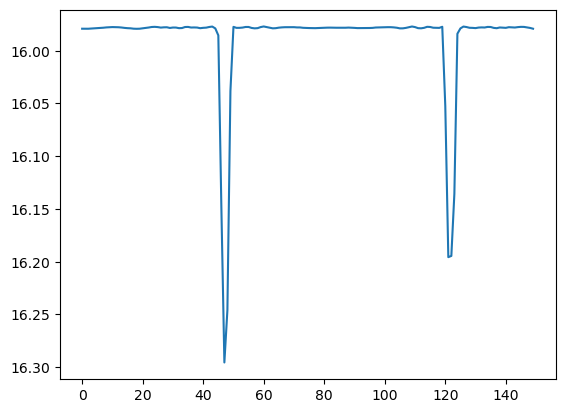

In [24]:
times_day = np.asarray(times) * yr_to_day

fig, ax = plt.subplots()
ax.plot(times_day, gaia_g_mag)
ax.axvspan(t1_p * yr_to_day, t4_p * yr_to_day,
           alpha=0.2, color='C1', label='Primary eclipse')
ax.axvspan(t1_s * yr_to_day, t4_s * yr_to_day,
           alpha=0.2, color='C2', label='Secondary eclipse')
ax.set_xlabel('Time [days]')
ax.set_ylabel('Gaia G magnitude')
ax.invert_yaxis()
ax.legend()
plt.show()

## Save the spectra and meshes

In [18]:
os.makedirs(output_dir, exist_ok=True)

with open(f'{output_dir}/tz_fornacis_data_{num_wavelengths}.pkl', 'wb') as f:
    pickle.dump({
        'spectra_body1': spectra_body1,
        'spectra_body2': spectra_body2,
        'mesh_body1': pb1,
        'mesh_body2': pb2,
        'wavelengths': vws,
        'times': times,
        'primary_eclipse_window_yr': primary_eclipse_window_yr,
        'secondary_eclipse_window_yr': secondary_eclipse_window_yr,
    }, f)

print(f"\u2713 Spectra data saved to {output_dir}/tz_fornacis_data_{num_wavelengths}.pkl")

✓ Spectra data saved to data/tz_fornacis_data_40000.pkl


In [19]:
spectra_body1

array([[[1.01994651e-07, 1.03838903e-07],
        [1.01509622e-07, 1.04157683e-07],
        [9.59595650e-08, 1.04337456e-07],
        ...,
        [1.01133078e-07, 1.02973786e-07],
        [1.02055661e-07, 1.03357200e-07],
        [1.00826838e-07, 1.02628183e-07]],

       [[1.02527549e-07, 1.03965879e-07],
        [1.01258611e-07, 1.03971182e-07],
        [9.65123586e-08, 1.04247182e-07],
        ...,
        [1.01398641e-07, 1.03151791e-07],
        [1.01747997e-07, 1.03282647e-07],
        [1.01210298e-07, 1.02794120e-07]],

       [[1.02689874e-07, 1.03961596e-07],
        [1.01480989e-07, 1.04133867e-07],
        [9.86791106e-08, 1.04135645e-07],
        ...,
        [1.01687692e-07, 1.03292349e-07],
        [1.01074120e-07, 1.03239875e-07],
        [1.01219831e-07, 1.02838289e-07]],

       ...,

       [[9.99236628e-08, 1.03524411e-07],
        [9.95902290e-08, 1.04072567e-07],
        [1.02634073e-07, 1.04115451e-07],
        ...,
        [9.59997585e-08, 1.02663870e-07],
     